In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import scanpy as sc 

In [2]:

# import importlib
# import SingleCellArchetype
# importlib.reload(SingleCellArchetype)
# importlib.reload(SingleCellArchetype.main)
# importlib.reload(SingleCellArchetype.utils)

from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype
from SingleCellArchetype.utils import get_relative_variation
from SingleCellArchetype.utils import shuffle_rows_per_col

# Load data

In [3]:
%%time
f_anndata_in  = "../../data/v1_multiome/superdupermegaRNA_hasraw_multiome_IT.h5ad"
adata = sc.read(f_anndata_in)

CPU times: user 2.61 s, sys: 18.8 s, total: 21.4 s
Wall time: 2min 22s


In [4]:
%%time
f_anndata_in  = "../../data/v1_multiome/run_sca/multiome_it_p21_hvg.h5ad"
adata_hvg = sc.read(f_anndata_in)
adata_hvg

CPU times: user 270 ms, sys: 986 ms, total: 1.26 s
Wall time: 8.4 s


AnnData object with n_obs × n_vars = 5399 × 4720
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'cond'
    var: 'feature_types'
    layers: 'lognorm', 'norm', 'zlognorm'

In [5]:
genes_hvg = adata_hvg.var.index.values

# Run SingleCellArchetype with different controls
- HVG (nHVGs) 
- PCA (ndim)
- number of archetypes (noc)
- level of pointedness (t-ratio)
- level of continuity (within type shuffling)
- enriched programs

In [6]:
from sklearn.decomposition import PCA

In [7]:
# types = [0]*len(adata_hvg)
types = adata_hvg.obs.Type.cat.codes
norm_mat = np.array(adata_hvg.layers['lognorm'])
sca = SCA(norm_mat, types)

In [8]:
x = norm_mat # [:,:300]
n_repeats = 20

nc, ng = x.shape
nc, ng, x.shape

(5399, 4720, (5399, 4720))

In [9]:
pca = PCA(n_components=10).fit(x)

shuffled_evs = []
for i in np.arange(n_repeats):
    x_gshuff = shuffle_rows_per_col(x)
    pca_gshuff = PCA(n_components=10).fit(x_gshuff)
    shuffled_evs.append(pca_gshuff.explained_variance_ratio_)

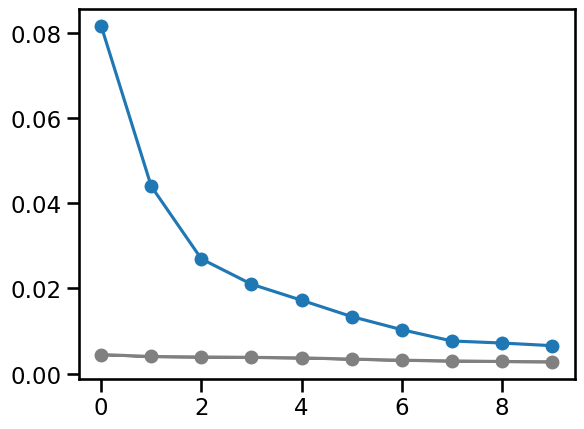

In [10]:
avg = np.mean(shuffled_evs, axis=0)
std = np.std(shuffled_evs, axis=0)

plt.plot(np.arange(10), pca.explained_variance_ratio_, '-o')
plt.plot(np.arange(10), avg, '-o', color='gray')
plt.fill_between(np.arange(10), 
                 avg-std, 
                 avg+std,
                 color='gray')

In [11]:
noc  = 3
ndim = noc-1
nrepeats = 3

In [12]:
# data 
sca.setup_feature_matrix(method='data')
xp, aa, _ = sca.proj_and_pcha(ndim, noc)
aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use data


## plot

In [13]:
types_colorvec = np.char.add('C', sca.types_idx.astype(str))

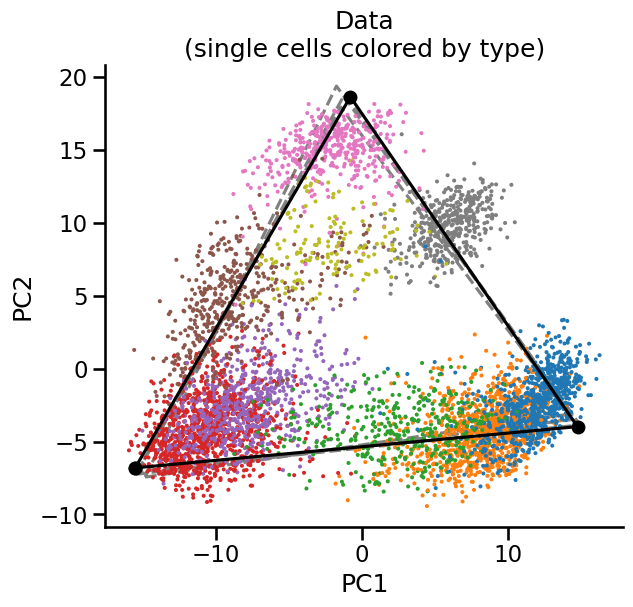

In [14]:
# plot
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
ax.scatter(xp[:,0], xp[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect('equal')
sns.despine(ax=ax)
ax.grid(False)
    
plt.show()

In [15]:
subclass_colorvec = np.char.add('C', adata_hvg.obs.Subclass.cat.codes.astype(str))

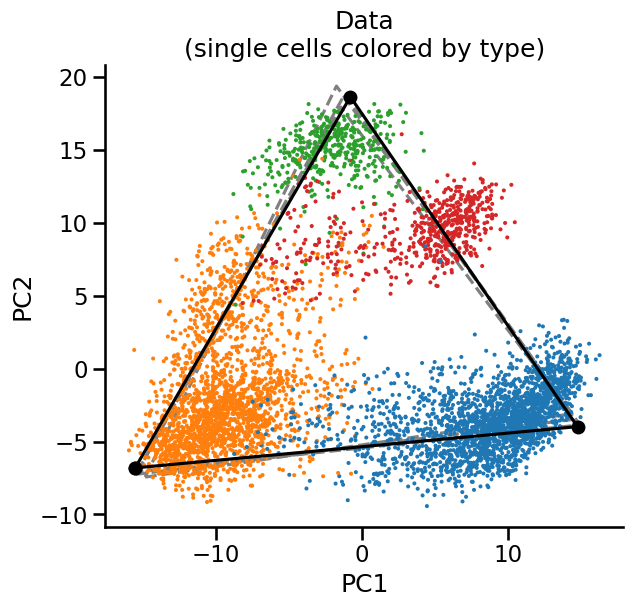

In [16]:
# plot
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
ax.scatter(xp[:,0], xp[:,1], c=subclass_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect('equal')
sns.despine(ax=ax)
ax.grid(False)
    
plt.show()

# define a transcriptomic order

In [17]:
adata_dpt = adata_hvg
adata_dpt.obsm['pca_later'] = PCA(n_components=10).fit_transform(sca.xn)
adata_dpt

AnnData object with n_obs × n_vars = 5399 × 4720
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'cond'
    var: 'feature_types'
    obsm: 'pca_later'
    layers: 'lognorm', 'norm', 'zlognorm'

In [18]:
pc1 = adata_dpt.obsm['pca_later'][:,0]
pc2 = adata_dpt.obsm['pca_later'][:,1]
gexp = np.array(adata_dpt[:,'Cdh13'].layers['norm']).reshape(-1,)

sc.pp.neighbors(adata_dpt, n_neighbors=30, use_rep='pca_later')
# adata_dpt.uns["iroot"] = np.argmax(gexp) 
adata_dpt.uns["iroot"] = np.argmax(pc1)
sc.tl.diffmap(adata_dpt)
sc.tl.dpt(adata_dpt)

In [19]:
num_bins = 50
xm = (1/2 + np.arange(0,num_bins,1))*1/num_bins
adata_dpt.obs['dpt'] = np.clip(adata_dpt.obs['dpt_pseudotime'].values, a_min=0, a_max=1)

adata_dpt.obs['dpt_bin']  = pd.cut( adata_dpt.obs['dpt'], num_bins, labels=False)
adata_dpt.obs['dpt_qbin'] = pd.qcut(adata_dpt.obs['dpt'], num_bins, labels=False)

cdf = adata_dpt.obs.groupby('dpt_bin').size()
cdf_by_subclass = adata_dpt.obs.groupby(['dpt_bin', 'Subclass']).size().unstack()
cdf_by_type = adata_dpt.obs.groupby(['dpt_bin', 'Type']).size().unstack()

qcdf = adata_dpt.obs.groupby('dpt_qbin').size()
qcdf_by_subclass = adata_dpt.obs.groupby(['dpt_qbin', 'Subclass']).size().unstack()
qcdf_by_type = adata_dpt.obs.groupby(['dpt_qbin', 'Type']).size().unstack()

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

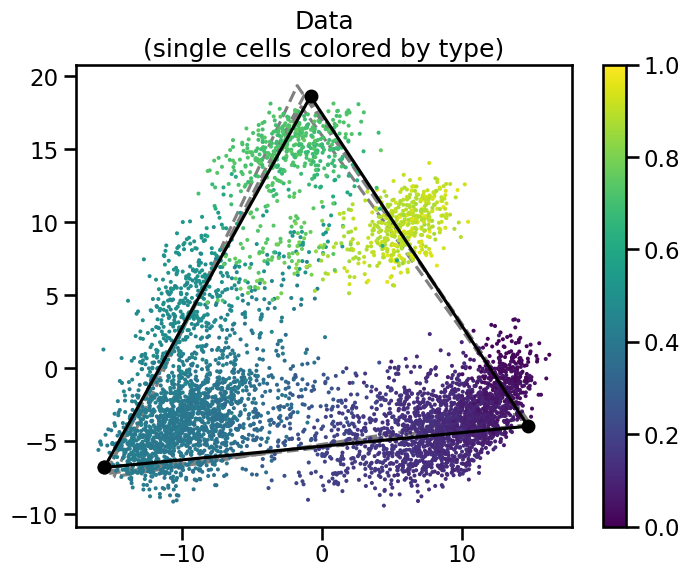

In [20]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=adata_dpt.obs['dpt'].values, s=2)
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

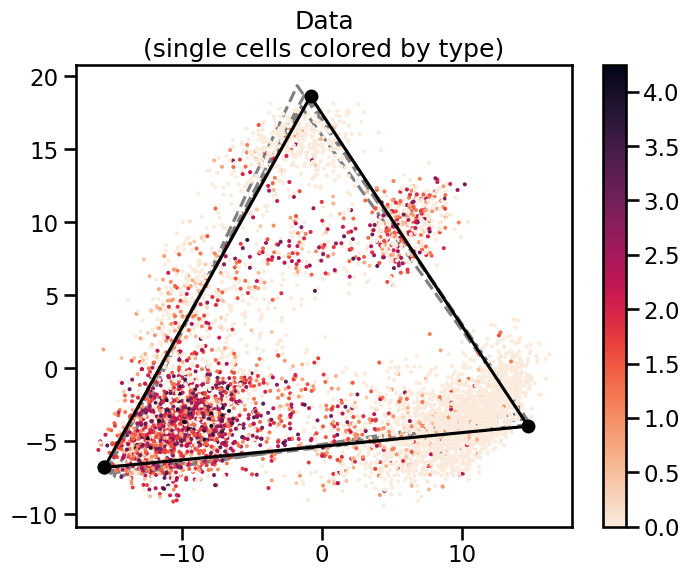

In [21]:
gexp = np.array(adata_dpt[:,'Chrm2'].layers['lognorm']).reshape(-1,)

fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=gexp, s=2, cmap='rocket_r')
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

# 3D plot

In [22]:
pcs = PCA(n_components=5).fit_transform(adata_hvg.layers['lognorm'][...])

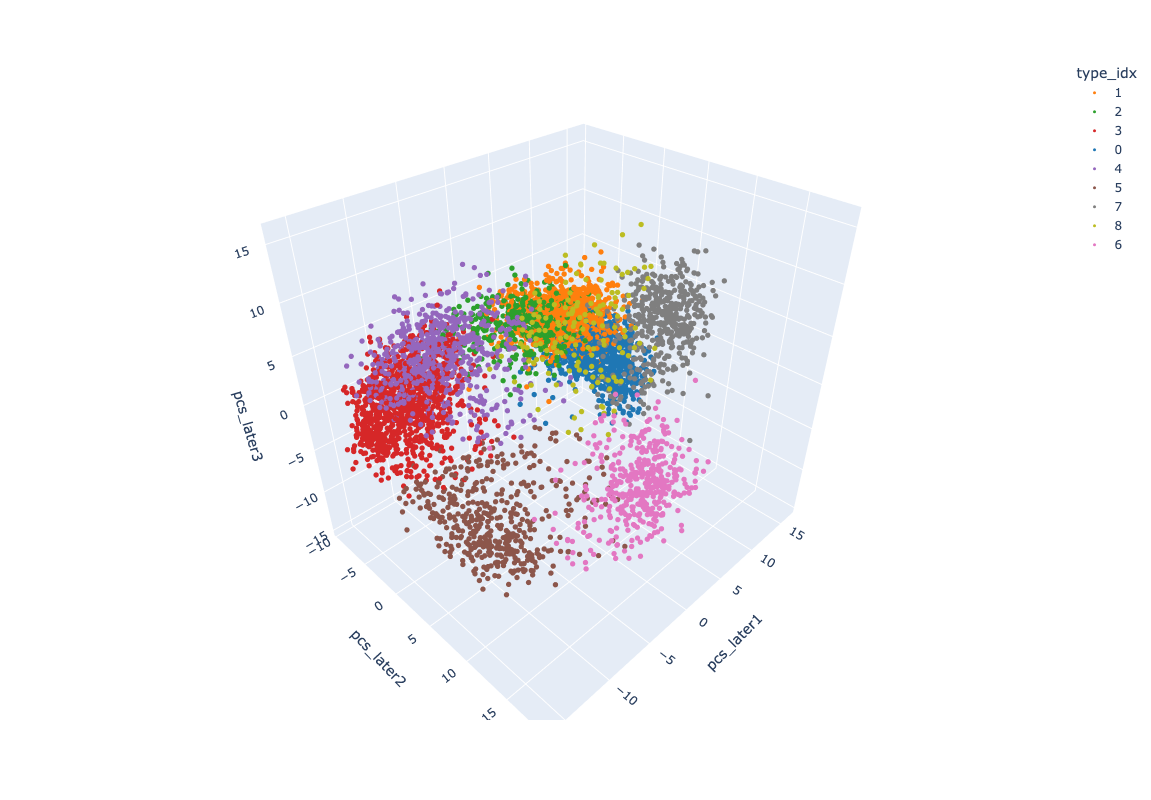

In [23]:
import plotly.express as px

mpl_colors = {
    '0': '#1f77b4', '1': '#ff7f0e', '2': '#2ca02c', '3': '#d62728', '4': '#9467bd',
    '5': '#8c564b', '6': '#e377c2', '7': '#7f7f7f', '8': '#bcbd22', '9': '#17becf'
}

df = pd.DataFrame()
df['pcs_later1'] = pcs[:,0]
df['pcs_later2'] = pcs[:,1]
df['pcs_later3'] = pcs[:,2]
df['type_idx'] = sca.types_idx.astype(str)

fig = px.scatter_3d(df, x='pcs_later1', y='pcs_later2', z='pcs_later3',
                      color='type_idx', 
                      color_discrete_map=mpl_colors,
                   )
fig.update_traces(marker_size=3) 
fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()


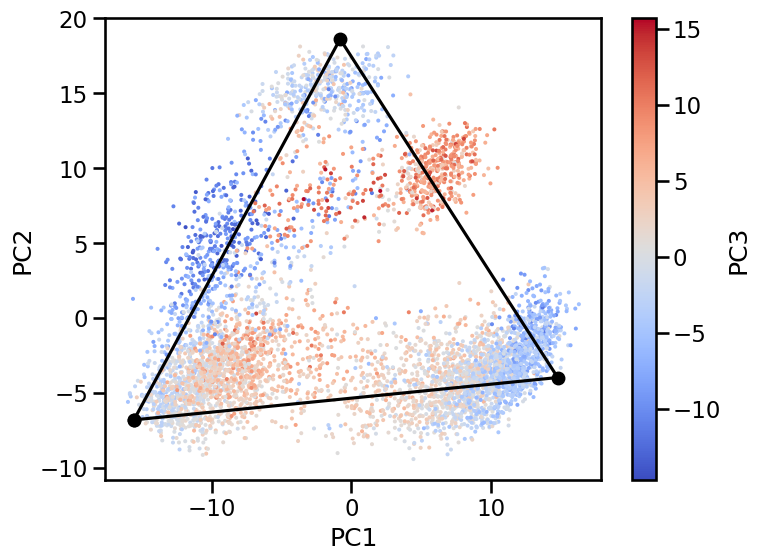

In [24]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(df['pcs_later1'], 
               df['pcs_later2'],
               c=df['pcs_later3'], s=2, cmap='coolwarm')
fig.colorbar(g, label='PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)

# gene expression as a function of the order
- for all genes 

In [25]:
# get all info
mat = np.log2(1+adata[adata_dpt.obs.index].layers['norm'])
df = pd.DataFrame(mat, columns=adata.var.index, index=adata_dpt.obs.index)
df['dpt'] = adata_dpt.obs['dpt']
df['dpt_bin'] = adata_dpt.obs['dpt_bin']
df['dpt_qbin'] = adata_dpt.obs['dpt_qbin']
yms = df.groupby('dpt_bin').mean()
qyms = df.groupby('dpt_qbin').mean()

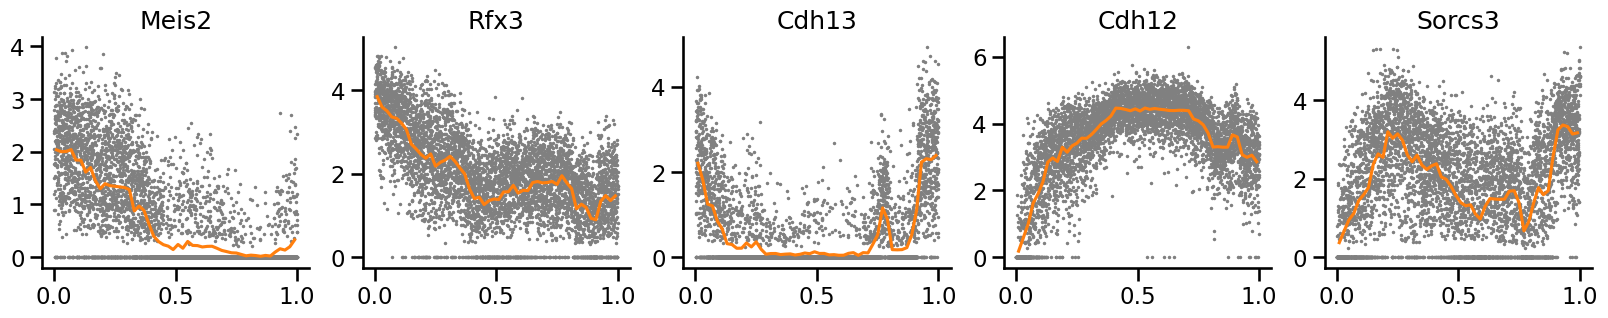

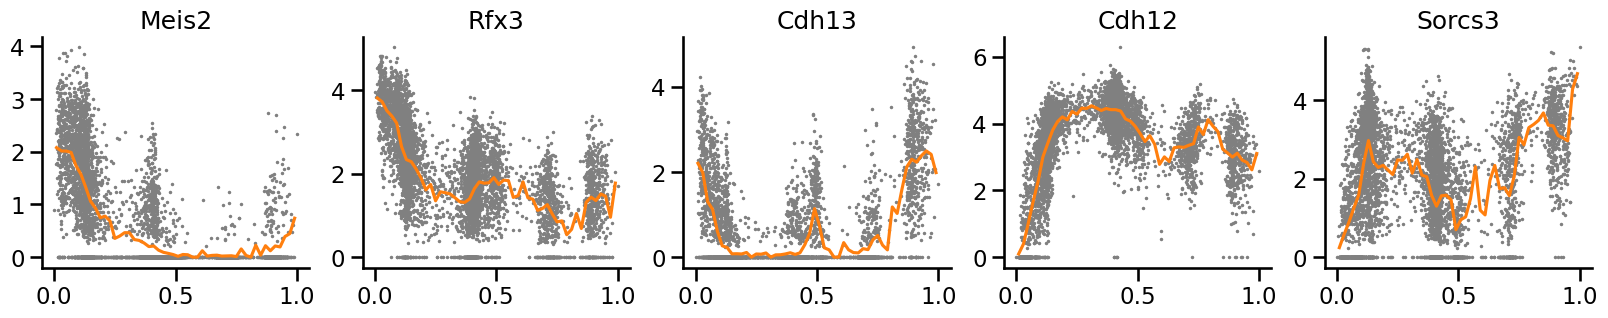

In [26]:
x  = adata_dpt.obs['dpt']
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Meis2', 'Rfx3', 'Cdh13', 'Cdh12', 'Sorcs3',]
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(qx, y, s=1, color='gray')
    
    ax.plot(xm, qyms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(x, y, s=1, color='gray')
    
    ax.plot(xm, yms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

# cell density along dpt as a control

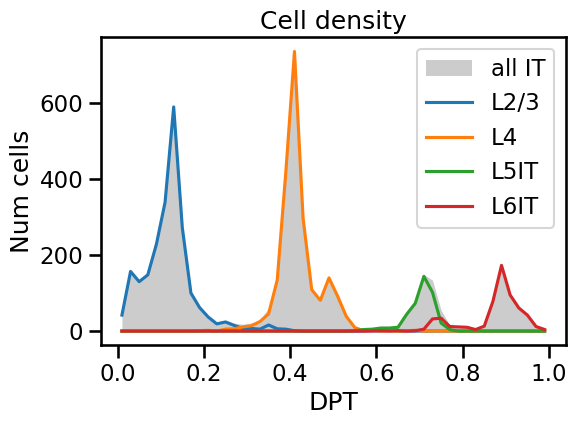

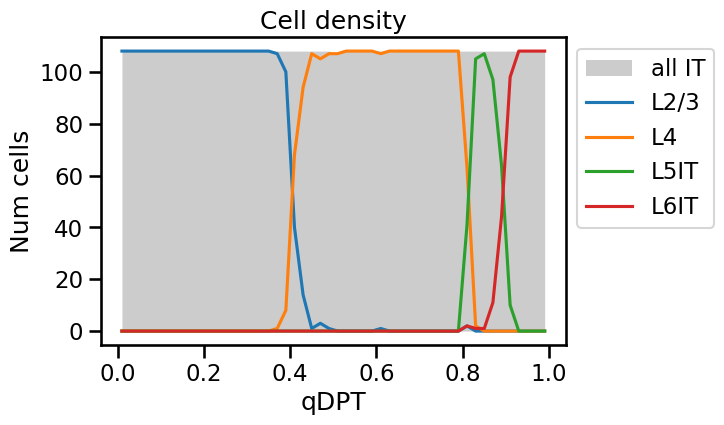

In [27]:
fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, cdf, color='k', label='all IT', alpha=0.2, linewidth=0)
subclasses = ['L2/3', 'L4', 'L5IT', 'L6IT']
for subclass in subclasses:
    ax.plot(xm, cdf_by_subclass[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('DPT')
ax.set_ylabel('Num cells')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, qcdf, color='k', label='all IT', alpha=0.2, linewidth=0)
subclasses = ['L2/3', 'L4', 'L5IT', 'L6IT']
for subclass in subclasses:
    ax.plot(xm, qcdf_by_subclass[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('qDPT')
ax.set_ylabel('Num cells')
plt.show()

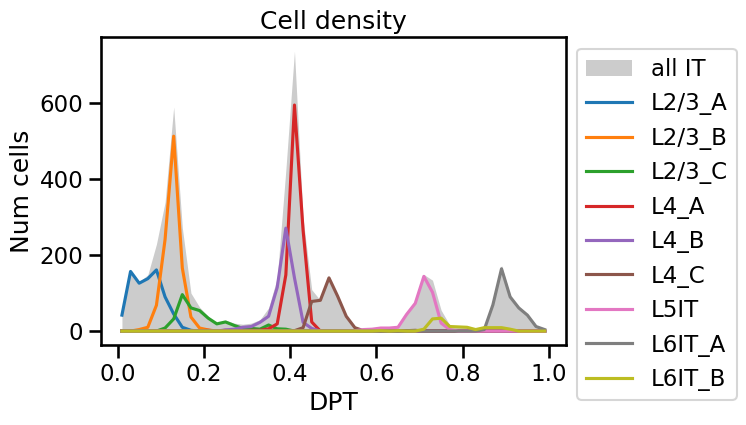

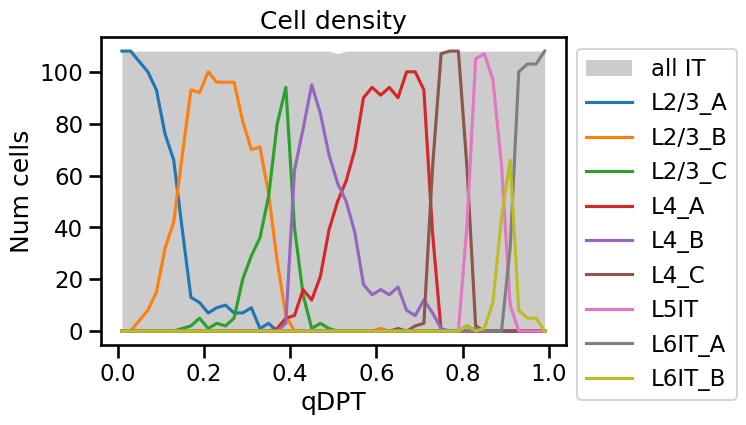

In [28]:
fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, cdf, color='k', label='all IT', alpha=0.2, linewidth=0)
for subclass in cdf_by_type.columns:
    ax.plot(xm, cdf_by_type[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('DPT')
ax.set_ylabel('Num cells')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, qcdf, color='k', label='all IT', alpha=0.2, linewidth=0)
for subclass in qcdf_by_type.columns:
    ax.plot(xm, qcdf_by_type[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('qDPT')
ax.set_ylabel('Num cells')
plt.show()

# Clustering

In [29]:
qyms_hvg = qyms[adata_dpt.var.index]
print(qyms_hvg.shape)

# remove noisy genes 
lfcs = qyms_hvg.max() - qyms_hvg.min()
qyms_hvg = qyms_hvg.T[lfcs>1].T
print(qyms_hvg.shape)

genes_selected = qyms_hvg.columns.values

qyms_hvg

(50, 4720)
(50, 497)


,Xkr4,Rgs20,Sntg1,Sgk3,A830018L16Rik,Kcnb2,Kcnq5,Rims1,Col19a1,Adgrb3,...,Trpm3,Pip5k1b,Rfx3,Prkg1,Cpeb3,Sorbs1,Crtac1,Sorcs3,Sorcs1,AC149090.1
dpt_qbin,,,,,,,,,,,,,,,,,,,,,
0,3.433980,0.168925,2.715830,1.373832,1.701726,3.827160,2.678793,3.529211,1.456802,5.028963,...,1.110264,1.100693,3.846255,4.038516,1.729729,1.534321,0.345648,0.369594,0.205520,1.681105
1,3.128476,0.380817,2.688745,1.011330,1.425460,3.807569,3.050050,3.317769,1.184557,4.901287,...,1.406320,0.997062,3.596418,3.863468,1.766228,1.362643,0.475638,0.668665,0.295861,2.005844
2,3.003585,0.813446,2.803316,1.007449,1.366371,3.824034,3.368079,3.431765,1.314592,4.954568,...,1.079976,0.945429,3.505727,3.773987,1.796909,1.392094,0.638119,0.951609,0.389538,2.204653
3,2.872134,0.797354,2.822371,0.885343,1.131051,3.902265,3.523695,3.448199,1.198446,4.908022,...,1.329283,0.972875,3.359649,3.837287,2.006363,1.183769,0.809378,1.116682,0.529145,1.980475
4,2.870132,0.810298,3.070295,1.040091,1.159354,3.944396,3.837876,3.583134,1.338156,4.911942,...,1.475761,1.103055,3.325707,3.725659,1.985274,1.223803,0.543115,1.442070,0.823440,1.832227
5,2.851460,0.740699,3.073529,0.946577,1.155272,4.144109,3.983005,3.608176,1.347525,4.857510,...,1.688104,1.001025,3.211366,3.796870,1.958473,1.034432,0.722958,1.589742,0.871375,1.608607
6,2.752784,0.863866,3.050993,0.968110,1.060139,3.952265,4.193057,3.684434,1.165991,4.858796,...,1.444997,1.101572,3.061205,3.737470,1.808709,1.026638,0.803364,1.772463,0.896011,1.774412
7,2.792825,0.772524,3.005866,0.895564,0.905511,4.007772,4.212217,3.757263,1.182873,4.741986,...,1.220451,1.110303,2.712512,3.633374,1.885022,1.242806,0.755819,2.370727,1.226778,1.926877
8,2.701646,1.056185,3.037638,0.776505,0.837136,4.131735,4.246148,3.812281,1.211153,4.746697,...,1.298299,1.043136,2.593396,3.488411,1.971092,1.414587,0.756280,2.631705,1.188982,1.798149


In [30]:
qzmat_hvg = (qyms_hvg-qyms_hvg.mean())/(1e-6+qyms_hvg.std())

In [31]:
from sklearn.cluster import KMeans

k = 10
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
kmeans.fit(qzmat_hvg.T)

labels = kmeans.labels_          # Cluster assignments for each point
centroids = kmeans.cluster_centers_  # Coordinates of cluster centers

kmeans_order = np.argsort(labels)
ordered_labels = labels[kmeans_order]
unq_labels, abn_counts = np.unique(ordered_labels, return_counts=True)
cum_counts = np.cumsum(abn_counts)

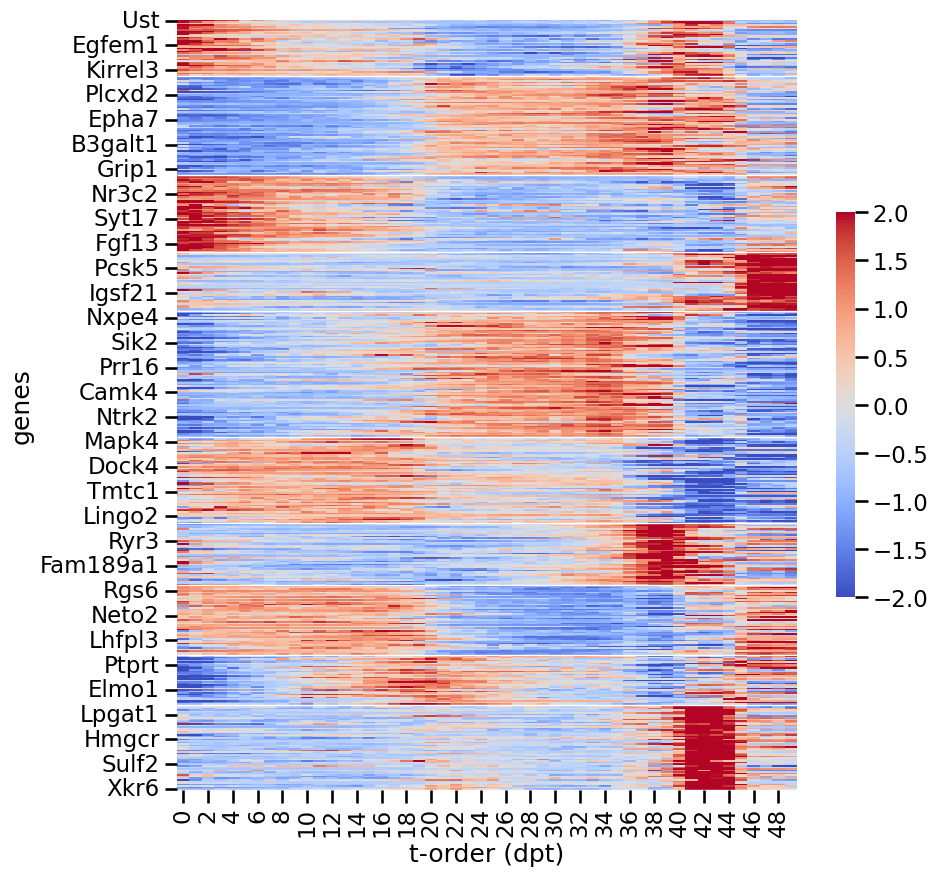

In [32]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(qzmat_hvg.T.iloc[kmeans_order], 
            cbar_kws=dict(shrink=0.5),
            cmap='coolwarm', vmax=2, vmin=-2, 
            ax=ax)
ax.hlines(cum_counts, xmin=0, xmax=100, color='white', linewidth=1)
ax.set_ylabel('genes')
ax.set_xlabel('t-order (dpt)')
plt.show()

In [33]:
from scroutines import basicu

queries = ['Cdh13', 'C1ql3']
labels[basicu.get_index_from_array(genes_selected, queries)]

array([3, 7], dtype=int32)

In [34]:
gpt = 1/num_bins*np.linspace(0,1,num_bins).dot(np.clip(qzmat_hvg, 0, None)/(1e-7+qzmat_hvg.max()))
# gpt = 1/num_bins*np.linspace(0,1,num_bins).dot((qzmat_hvg-qzmat_hvg.min())/(1e-7+qzmat_hvg.max()))

allgenes_ordered = []
allgenes_avg_gpt = []
for i in range(k):
    genes_sel = genes_selected[labels==i]
    gpt_sel = gpt[labels==i]
    sel_order = np.argsort(gpt_sel)
    avg_gpt = np.mean(gpt_sel)
    
    genes_ordered = genes_sel[sel_order]
    allgenes_ordered.append(genes_ordered)
    allgenes_avg_gpt.append(avg_gpt)

# reassign cluster memberships
allgenes_ordered = np.array(allgenes_ordered, dtype=object)[
    np.argsort(allgenes_avg_gpt)]# np.hstack(allgenes_ordered_new)

allgenes_ordered = np.hstack(allgenes_ordered)
# allgenes_ordered

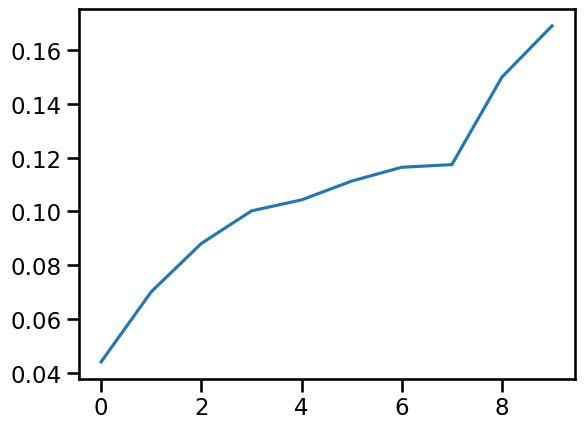

In [35]:
plt.plot(np.array(allgenes_avg_gpt)[np.argsort(allgenes_avg_gpt)])

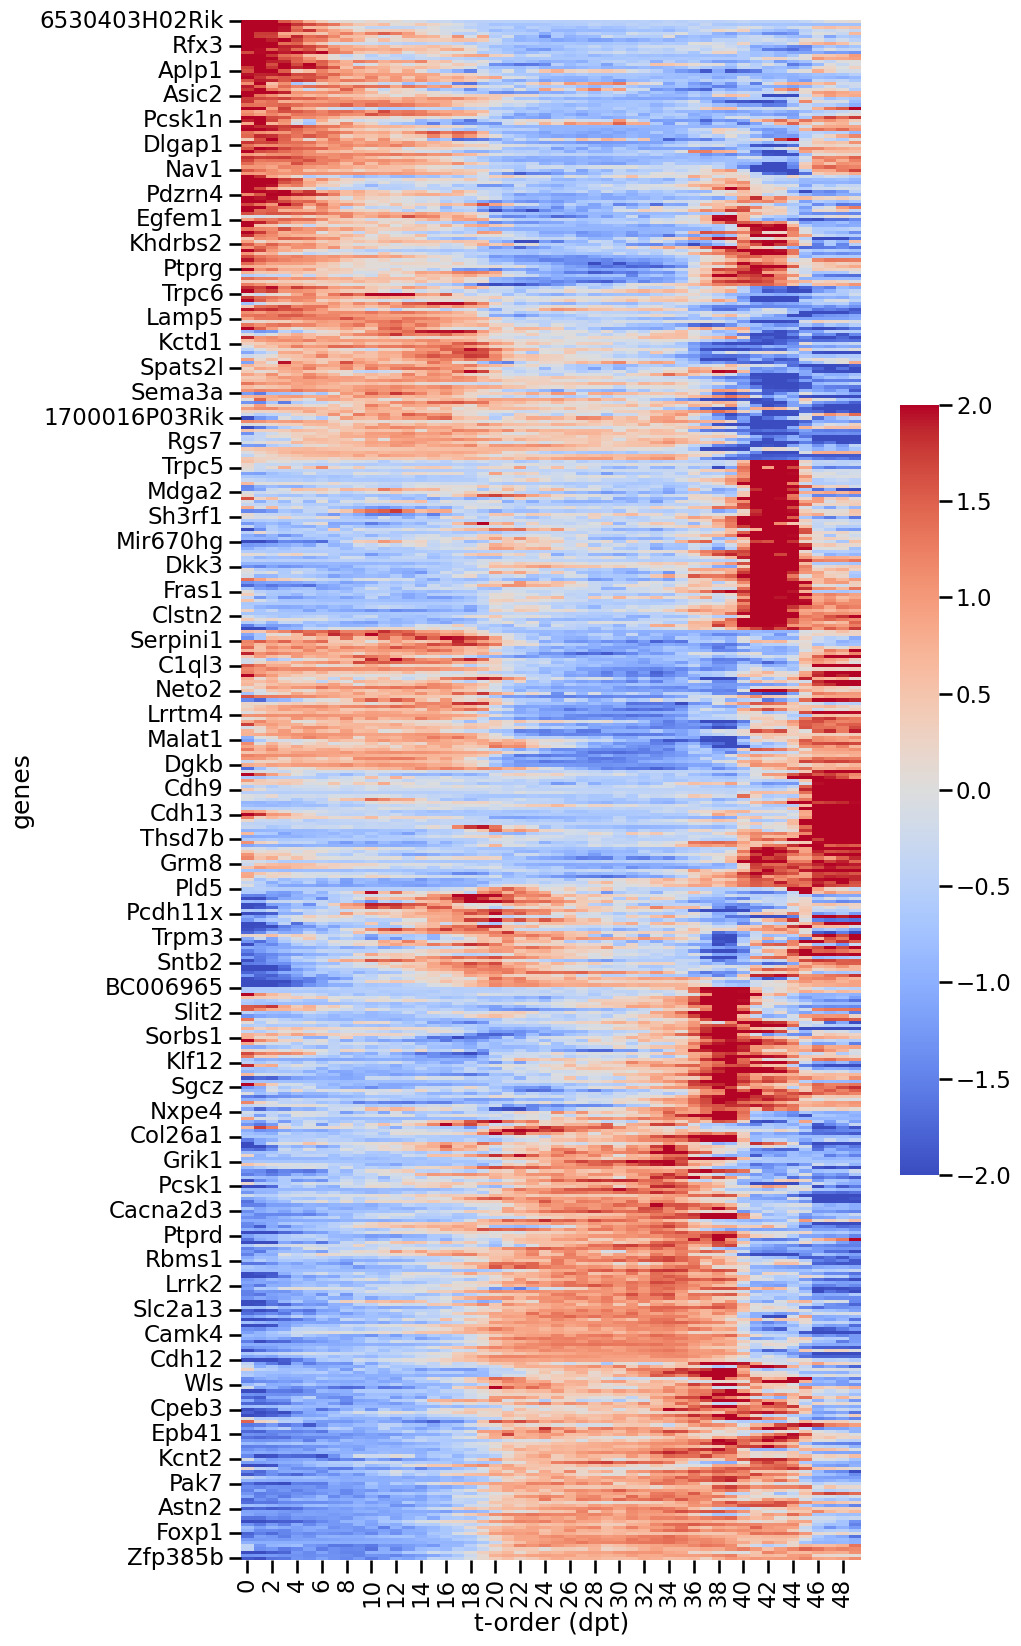

In [36]:
fig, ax = plt.subplots(figsize=(10,20))
sns.heatmap(qzmat_hvg.T.loc[allgenes_ordered], # .iloc[gene_order], 
            cbar_kws=dict(shrink=0.5),
            cmap='coolwarm', vmax=2, vmin=-2, 
            ax=ax)
# ax.hlines(cum_counts, xmin=0, xmax=100, color='white', linewidth=1)
ax.set_ylabel('genes')
ax.set_xlabel('t-order (dpt)')
plt.show()

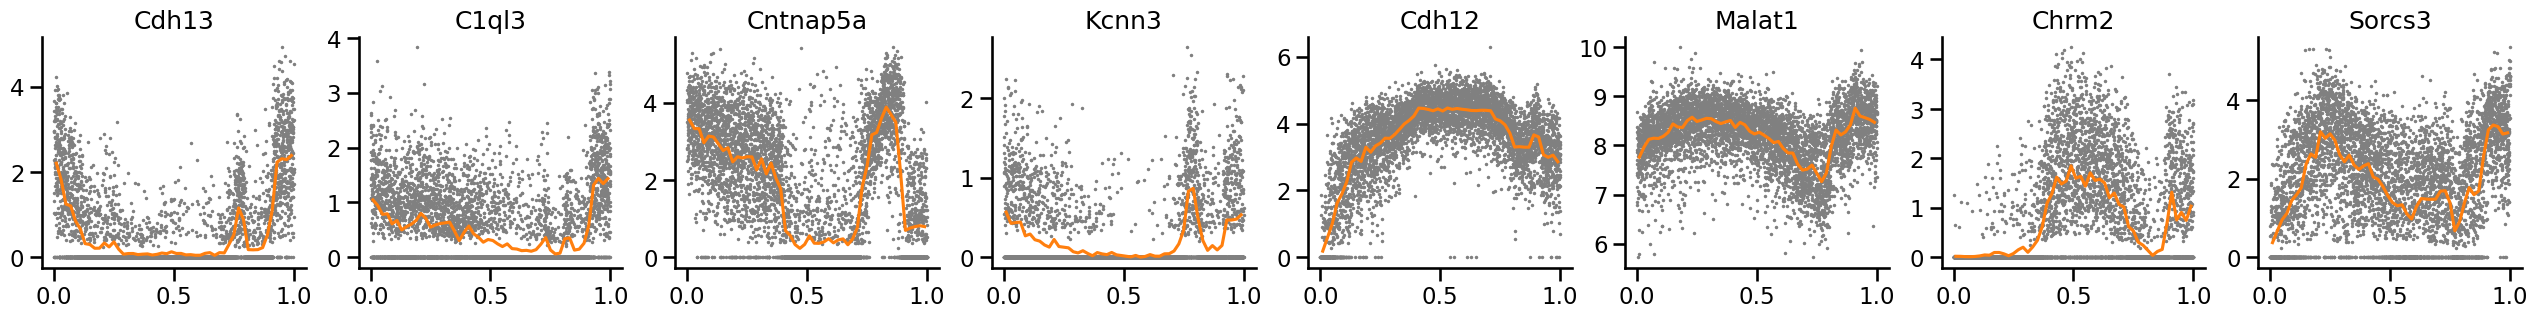

In [37]:
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Cdh13', 'C1ql3', 'Cntnap5a', 'Kcnn3', 'Cdh12', 'Malat1', 'Chrm2', 'Sorcs3']
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(qx, y, s=1, color='gray')
    
    ax.plot(xm, qyms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

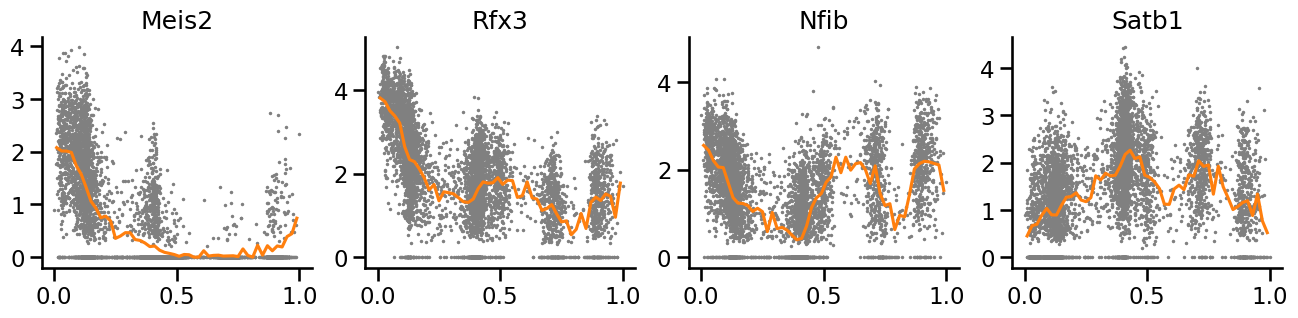

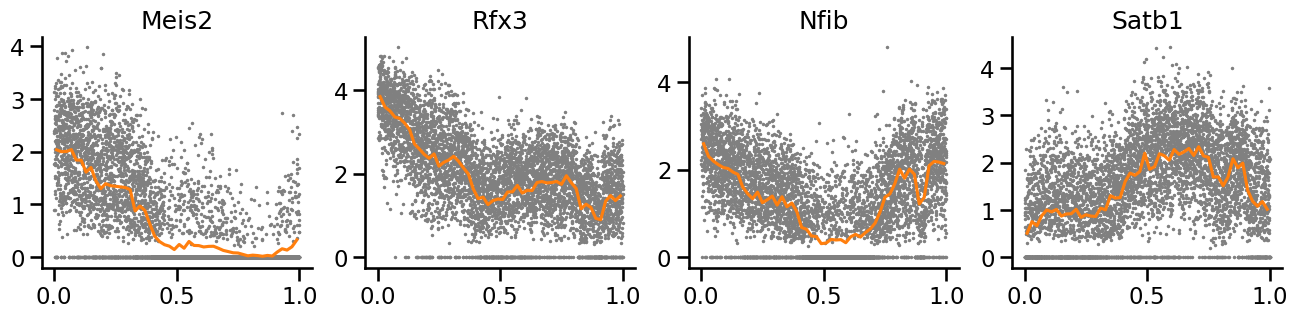

In [38]:
x = adata_dpt.obs['dpt']
qx = adata_dpt.obs['dpt'].rank(pct=True)
gns = ['Meis2', 'Rfx3', 'Nfib', 'Satb1']
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(x, y, s=1, color='gray')
    
    ax.plot(xm, yms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()


fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(qx, y, s=1, color='gray')
    
    ax.plot(xm, qyms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

In [39]:
# adata_dpt.obs[['sample', 'Class', 'Subclass', 'Type', 'dpt', 'dpt_bin', 'dpt_qbin']].to_csv('v1_multiome_P21_dpt.csv')

# explore more gene programs
- gene DPT
- Meis2 as the seed

In [40]:
adata_dpt_gene = adata_hvg.T[lfcs>1]
adata_dpt_gene.obsm['pca_later'] = PCA(n_components=10).fit_transform(qzmat_hvg.T)
adata_dpt_gene

AnnData object with n_obs × n_vars = 497 × 5399
    obs: 'feature_types'
    var: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'cond', 'dpt_pseudotime', 'dpt', 'dpt_bin', 'dpt_qbin'
    uns: 'neighbors', 'iroot', 'diffmap_evals'
    obsm: 'pca_later'
    varm: 'pca_later', 'X_diffmap'
    layers: 'lognorm', 'norm', 'zlognorm'
    varp: 'distances', 'connectivities'

In [41]:
pc1 = adata_dpt_gene.obsm['pca_later'][:,0]
pc2 = adata_dpt_gene.obsm['pca_later'][:,1]
pc3 = adata_dpt_gene.obsm['pca_later'][:,2]
idx = basicu.get_index_from_array(adata_dpt_gene.obs.index, ['Meis2'])[0]

sc.pp.neighbors(adata_dpt_gene, n_neighbors=30, use_rep='pca_later')
# adata_dpt_gene.uns["iroot"] = idx
adata_dpt_gene.uns["iroot"] = np.argmax(pc1)
sc.tl.diffmap(adata_dpt_gene)
sc.tl.dpt(adata_dpt_gene)

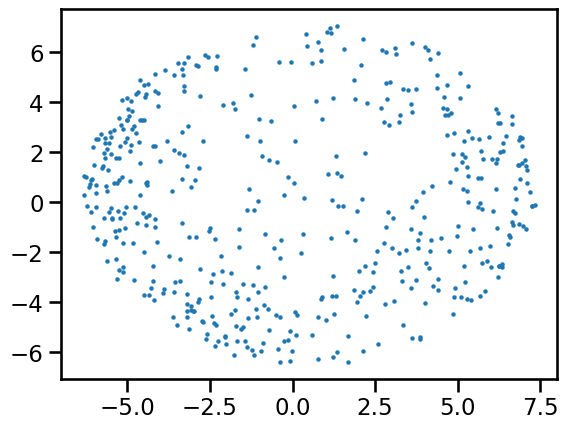

In [42]:
plt.scatter(pc1, pc2, s=3)

In [43]:
num_bins = 50
xm = (1/2 + np.arange(0,num_bins,1))*1/num_bins
adata_dpt_gene.obs['dpt'] = np.clip(adata_dpt_gene.obs['dpt_pseudotime'].values, a_min=0, a_max=1)

adata_dpt_gene.obs['dpt_bin']  = pd.cut( adata_dpt_gene.obs['dpt'], num_bins, labels=False)
adata_dpt_gene.obs['dpt_qbin'] = pd.qcut(adata_dpt_gene.obs['dpt'], num_bins, labels=False)

In [44]:
genes_order_dpt = adata_dpt_gene.obs.sort_values('dpt').index.values
# genes_order_dpt

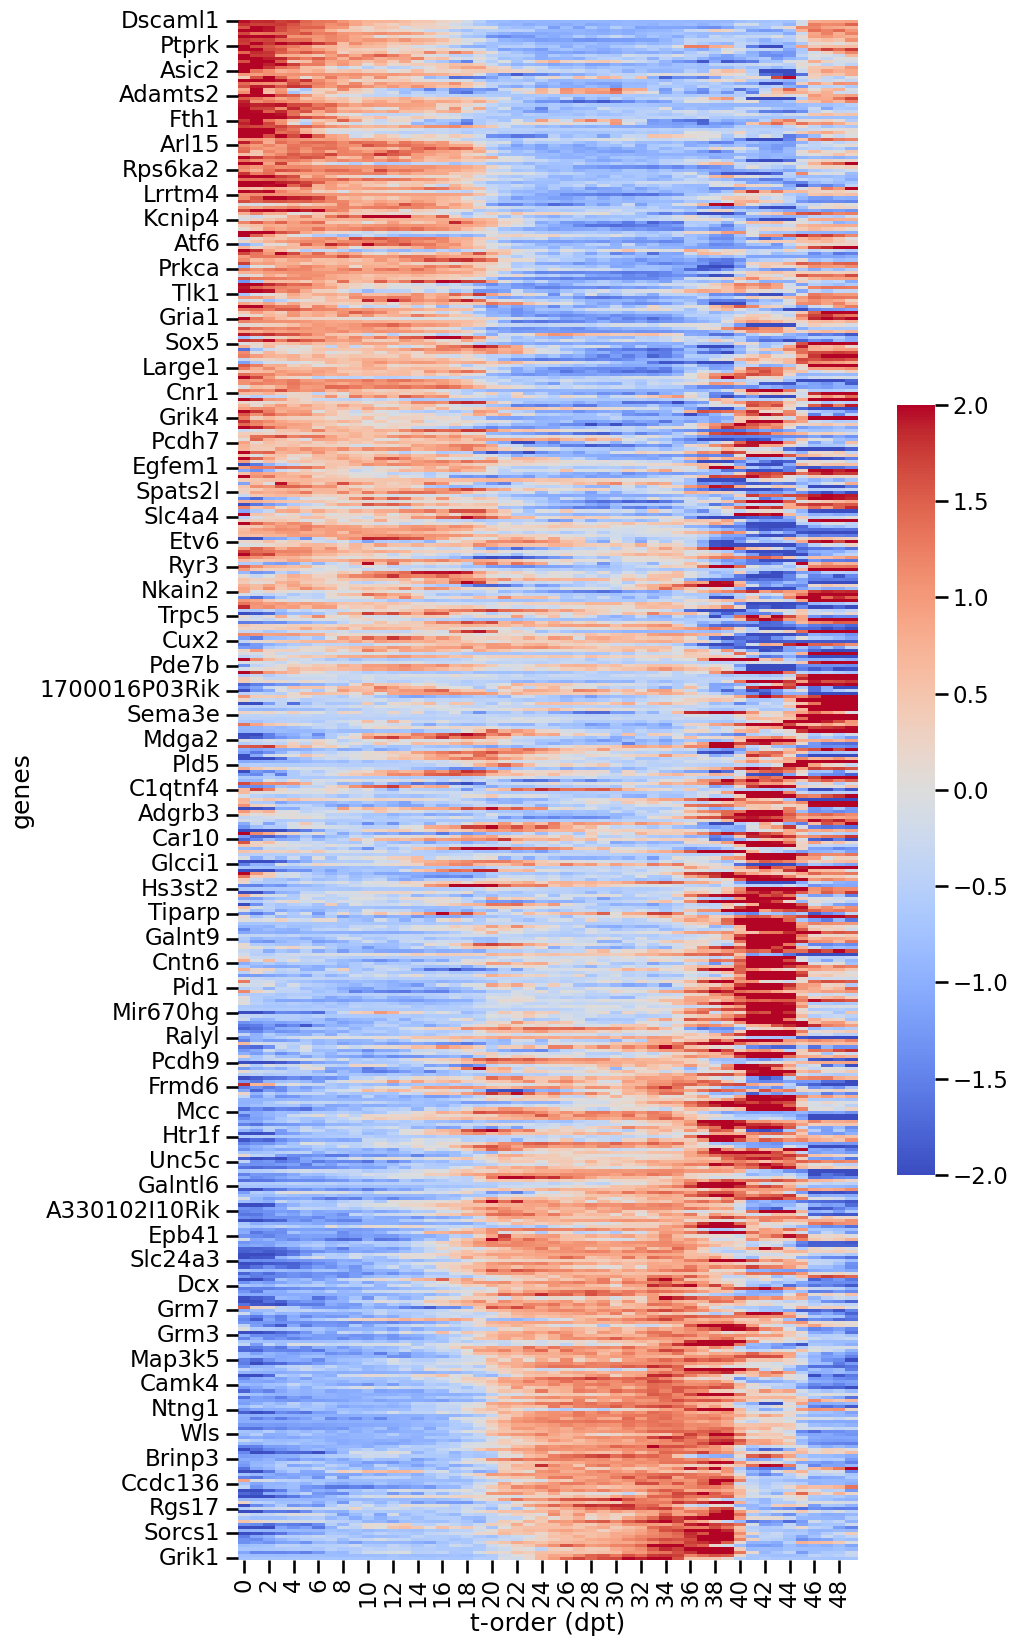

In [45]:
fig, ax = plt.subplots(figsize=(10,20))
sns.heatmap(qzmat_hvg.T.loc[genes_order_dpt], # .iloc[gene_order], 
            cbar_kws=dict(shrink=0.5),
            cmap='coolwarm', vmax=2, vmin=-2, 
            ax=ax)
# ax.hlines(cum_counts, xmin=0, xmax=100, color='white', linewidth=1)
ax.set_ylabel('genes')
ax.set_xlabel('t-order (dpt)')
plt.show()

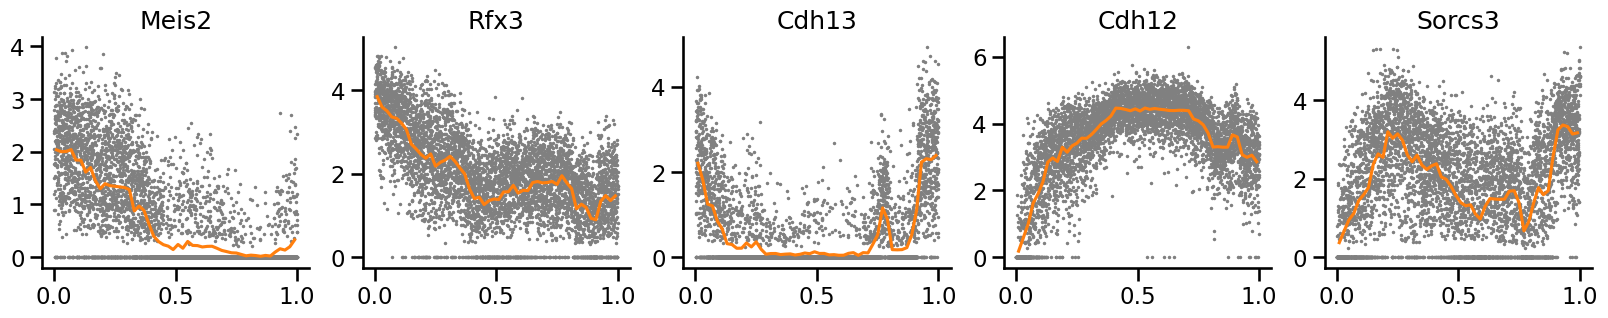

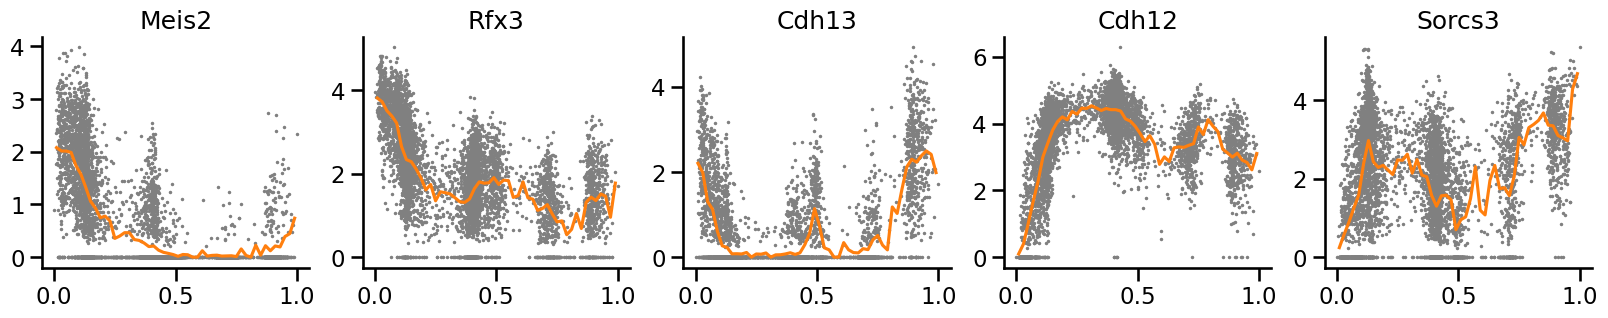

In [46]:
x  = adata_dpt.obs['dpt']
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Meis2', 'Rfx3', 'Cdh13', 'Cdh12', 'Sorcs3',]
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(qx, y, s=1, color='gray')
    
    ax.plot(xm, qyms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(x, y, s=1, color='gray')
    
    ax.plot(xm, yms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()